# FANet: Feedback Attention Network for Biomedical Image Segmentation

**Paper**: IEEE TNNLS 2022 | **arXiv**: 2103.17235 | **Author**: Nikhil Kumar Tomar et al.

This notebook trains & evaluates FANet on Kvasir-SEG polyp segmentation dataset.

## 1. Setup & Install Dependencies

In [1]:
!pip install -q albumentations opencv-python-headless tqdm scikit-learn

In [2]:
import os, time, random
import numpy as np
import cv2
from tqdm import tqdm
import albumentations as A

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.utils import shuffle as sk_shuffle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM:  {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
VRAM:  15.6 GB


## 2. Auto-detect Dataset Path

Kaggle datasets mounted at `/kaggle/input/`. Auto-detect which one is Kvasir-SEG.

In [3]:
CANDIDATES = [
    "/kaggle/input/kvasir-seg",
    "/kaggle/input/kvasir-sessile",
    "/kaggle/input/cvc-clinicdb",
    "/kaggle/input/chase-db1",
    "/kaggle/input/drive-vessel",
]

SRC_PATH = None
for p in CANDIDATES:
    if os.path.isdir(p) and os.path.isdir(f"{p}/images"):
        SRC_PATH = p
        break

if SRC_PATH is None:
    for root, dirs, _ in os.walk("/kaggle/input"):
        if "images" in dirs and "masks" in dirs:
            SRC_PATH = root
            break

assert SRC_PATH is not None, "Dataset not found. Add Kvasir-SEG via Kaggle Data panel."
print(f"Source: {SRC_PATH}")

n_img = len([f for f in os.listdir(f"{SRC_PATH}/images") if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))])
n_msk = len([f for f in os.listdir(f"{SRC_PATH}/masks") if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))])
print(f"Images: {n_img}, Masks: {n_msk}")

# /kaggle/input is read-only -> copy to /kaggle/working/
DATASET_PATH = "/kaggle/working/Kvasir-SEG"
if not os.path.exists(DATASET_PATH):
    print(f"Copying dataset to {DATASET_PATH} ...")
    !cp -r "{SRC_PATH}" "{DATASET_PATH}"

# Generate train.txt / val.txt
if not os.path.exists(f"{DATASET_PATH}/train.txt"):
    names = sorted([os.path.splitext(f)[0] for f in os.listdir(f"{DATASET_PATH}/images") if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))])
    np.random.seed(42); np.random.shuffle(names)
    split = int(len(names) * 0.8)
    with open(f"{DATASET_PATH}/train.txt", 'w') as f:
        f.write("\n".join(names[:split]) + "\n")
    with open(f"{DATASET_PATH}/val.txt", 'w') as f:
        f.write("\n".join(names[split:]) + "\n")
    print(f"Split: train={split}, val={len(names)-split}")

Source: /kaggle/input/datasets/namnguynnnn/kvasir-sessile
Images: 196, Masks: 196
Copying dataset to /kaggle/working/Kvasir-SEG ...


## 3. Model Components (blocks.py)

In [4]:
class SELayer(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)


class ResidualBlock(nn.Module):
    """3x3->3x3 residual block with SE attention."""
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_c)
        self.conv3 = nn.Conv2d(in_c, out_c, 1, padding=0)
        self.bn3 = nn.BatchNorm2d(out_c)
        self.se = SELayer(out_c, out_c)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x1 = self.relu(self.bn1(self.conv1(x)))
        x2 = self.bn2(self.conv2(x1))
        x3 = self.se(self.bn3(self.conv3(x)))
        return self.relu(x2 + x3)


class MixPool(nn.Module):
    """Feedback attention: merges image features with previous-epoch mask."""
    def __init__(self, in_c, out_c):
        super().__init__()
        self.fmask = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, 1, 1, padding=0),
            nn.Sigmoid()
        )
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_c, out_c // 2, 3, padding=1),
            nn.BatchNorm2d(out_c // 2),
            nn.ReLU(inplace=True)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_c, out_c // 2, 3, padding=1),
            nn.BatchNorm2d(out_c // 2),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, m):
        fmask = (self.fmask(x) > 0.5).float()
        m = nn.MaxPool2d((m.shape[2] // x.shape[2], m.shape[3] // x.shape[3]))(m)
        x1 = x * torch.logical_or(fmask > 0, m > 0).float()
        x1 = self.conv1(x1)
        x2 = self.conv2(x)
        return torch.cat([x1, x2], dim=1)

## 4. FANet Model (model.py)

In [5]:
class EncoderBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.r1 = ResidualBlock(in_c, out_c)
        self.r2 = ResidualBlock(out_c, out_c)
        self.p1 = MixPool(out_c, out_c)
        self.pool = nn.MaxPool2d(2)

    def forward(self, inputs, masks):
        x = self.r2(self.r1(inputs))
        p = self.p1(x, masks)
        return self.pool(p), x


class DecoderBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.upsample = nn.ConvTranspose2d(in_c, in_c, 4, stride=2, padding=1)
        self.r1 = ResidualBlock(in_c * 2, out_c)
        self.r2 = ResidualBlock(out_c, out_c)
        self.p1 = MixPool(out_c, out_c)

    def forward(self, inputs, skip, masks):
        x = self.upsample(inputs)
        x = torch.cat([x, skip], dim=1)
        x = self.r2(self.r1(x))
        return self.p1(x, masks)


class FANet(nn.Module):
    def __init__(self):
        super().__init__()
        self.e1 = EncoderBlock(3, 32)
        self.e2 = EncoderBlock(32, 64)
        self.e3 = EncoderBlock(64, 128)
        self.e4 = EncoderBlock(128, 256)
        self.d1 = DecoderBlock(256, 128)
        self.d2 = DecoderBlock(128, 64)
        self.d3 = DecoderBlock(64, 32)
        self.d4 = DecoderBlock(32, 16)
        self.output = nn.Conv2d(16 + 1, 1, kernel_size=1)

    def forward(self, x):
        inputs, masks = x[0], x[1]
        p1, s1 = self.e1(inputs, masks)
        p2, s2 = self.e2(p1, masks)
        p3, s3 = self.e3(p2, masks)
        p4, s4 = self.e4(p3, masks)
        d1 = self.d1(p4, s4, masks)
        d2 = self.d2(d1, s3, masks)
        d3 = self.d3(d2, s2, masks)
        d4 = self.d4(d3, s1, masks)
        return self.output(torch.cat([d4, masks], dim=1))


# Quick sanity check
model = FANet().to(device)
params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {params:,}")
x = torch.randn(1, 3, 256, 256).to(device)
m = torch.randn(1, 1, 256, 256).to(device)
with torch.no_grad():
    y = model([x, m])
print(f"Input: {x.shape} + {m.shape}  ->  Output: {y.shape}")

Total parameters: 7,720,266
Input: torch.Size([1, 3, 256, 256]) + torch.Size([1, 1, 256, 256])  ->  Output: torch.Size([1, 1, 256, 256])


## 5. Loss Functions (loss.py)

In [6]:
class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, inputs, targets, smooth=1e-5):
        inputs = torch.sigmoid(inputs).view(-1)
        targets = targets.view(-1)
        intersection = (inputs * targets).sum()
        dice_loss = 1 - (2. * intersection + smooth) / (inputs.sum() + targets.sum() + smooth)
        bce = nn.functional.binary_cross_entropy(inputs, targets, reduction='mean')
        return 0.5 * bce + 0.5 * dice_loss

## 6. Utilities (RLE, Otsu, Data Loading)

In [7]:
def rle_encode(x):
    """x: (H,W) uint8, 1=mask. Returns RLE as list of ints."""
    dots = np.where(x.T.flatten() == 1)[0]
    run_lengths = []
    prev = -2
    for b in dots:
        if b > prev + 1:
            run_lengths.extend((b + 1, 0))
        run_lengths[-1] += 1
        prev = b
    return run_lengths


def rle_decode(mask_rle, shape):
    """mask_rle: str 's1 l1 s2 l2 ...', shape: (H,W). Returns uint8 array."""
    s = mask_rle.split()
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[0:][::2], s[1:][::2])]
    starts -= 1
    ends = starts + lengths
    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(shape, order='F')


def init_mask(image_paths, size=(256, 256)):
    """Otsu thresholding -> RLE-encoded masks for epoch 0."""
    masks = []
    for p in tqdm(image_paths, desc="Otsu init"):
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, size)
        blur = cv2.GaussianBlur(img, (5, 5), 0)
        _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        th = (th / 255.0 > 0.5).astype(np.int32)
        masks.append(rle_encode(th))
    return masks


def load_data(path):
    """Read train.txt / val.txt -> (images[], masks[]). Supports jpg/png/tif."""
    def _load(p, fname):
        with open(f"{p}/{fname}") as f:
            data = f.read().split("\n")[:-1]
        imgs, msks = [], []
        for n in data:
            for ext in (".jpg", ".jpeg", ".png", ".tif", ".tiff"):
                if os.path.exists(os.path.join(p, "images", n + ext)):
                    imgs.append(os.path.join(p, "images", n + ext))
                    msks.append(os.path.join(p, "masks", n + ext))
                    break
        return imgs, msks
    return _load(path, "train.txt"), _load(path, "val.txt")


def seeding(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True

## 7. Dataset & DataLoader

In [8]:
class KvasirDataset(Dataset):
    def __init__(self, img_paths, mask_paths, size=(256, 256), transform=None):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.size = size
        self.transform = transform

    def __getitem__(self, idx):
        img = cv2.imread(self.img_paths[idx], cv2.IMREAD_COLOR)
        msk = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        if self.transform:
            aug = self.transform(image=img, mask=msk)
            img, msk = aug["image"], aug["mask"]
        img = cv2.resize(img, self.size)
        img = np.transpose(img, (2, 0, 1)) / 255.0
        msk = cv2.resize(msk, self.size)
        msk = np.expand_dims(msk, axis=0) / 255.0
        return img.astype(np.float32), msk.astype(np.float32)

    def __len__(self):
        return len(self.img_paths)


seeding(42)
(train_x, train_y), (valid_x, valid_y) = load_data(DATASET_PATH)
train_x, train_y = sk_shuffle(train_x, train_y, random_state=42)

print(f"Train:       {len(train_x)} images")
print(f"Validation:  {len(valid_x)} images")
print(f"Sample:      {os.path.basename(train_x[0])}")

transform = A.Compose([
    A.Rotate(limit=35, p=0.3),
    A.HorizontalFlip(p=0.3),
    A.VerticalFlip(p=0.3),
    A.CoarseDropout(p=0.3, max_holes=10, max_height=32, max_width=32),
])

BATCH = 4
train_ds = KvasirDataset(train_x, train_y, transform=transform)
valid_ds = KvasirDataset(valid_x, valid_y)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=False, num_workers=2)
valid_loader = DataLoader(valid_ds, batch_size=BATCH, shuffle=False, num_workers=2)

Train:       156 images
Validation:  40 images
Sample:      cju6us80mv1b50871ebyq2wxa.jpg


/tmp/ipykernel_23/1105060998.py:36: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(p=0.3, max_holes=10, max_height=32, max_width=32),


## 8. Training & Evaluation Functions

In [9]:
def train_epoch(model, loader, mask_list, opt, loss_fn, device):
    model.train()
    total_loss, new_masks = 0, []
    for i, (x, y) in enumerate(loader):
        x, y = x.to(device), y.to(device)
        b = y.shape[0]

        m_batch = []
        for edata in mask_list[i * BATCH : i * BATCH + b]:
            s = " ".join(str(d) for d in edata)
            dec = rle_decode(s, (256, 256))
            m_batch.append(np.expand_dims(dec, 0))

        m_batch = np.transpose(np.array(m_batch, dtype=np.int32), (0, 1, 3, 2))
        m_batch = torch.from_numpy(m_batch).to(device, dtype=torch.float32)

        opt.zero_grad()
        pred = model([x, m_batch])
        loss = loss_fn(pred, y)
        loss.backward()
        opt.step()

        with torch.no_grad():
            for py in (torch.sigmoid(pred) > 0.5).cpu().numpy().astype(np.uint8):
                new_masks.append(rle_encode(np.squeeze(py, 0)))

        total_loss += loss.item()
    return total_loss / len(loader), new_masks


def eval_epoch(model, loader, mask_list, loss_fn, device):
    model.eval()
    total_loss, new_masks = 0, []
    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            x, y = x.to(device), y.to(device)
            b = y.shape[0]

            m_batch = []
            for edata in mask_list[i * BATCH : i * BATCH + b]:
                s = " ".join(str(d) for d in edata)
                dec = rle_decode(s, (256, 256))
                m_batch.append(np.expand_dims(dec, 0))

            m_batch = np.transpose(np.array(m_batch, dtype=np.int32), (0, 1, 3, 2))
            m_batch = torch.from_numpy(m_batch).to(device, dtype=torch.float32)

            pred = model([x, m_batch])
            loss = loss_fn(pred, y)
            total_loss += loss.item()

            for py in (torch.sigmoid(pred) > 0.5).cpu().numpy().astype(np.uint8):
                new_masks.append(rle_encode(np.squeeze(py, 0)))

    return total_loss / len(loader), new_masks

## 9. Train the Model

In [10]:
NUM_EPOCHS = 200
LR = 1e-4
CKPT = "checkpoint.pth"

model = FANet().to(device)
opt = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', patience=5)
loss_fn = DiceBCELoss()

print(f"Device:    {device}")
print(f"Model:     {sum(p.numel() for p in model.parameters()):,} params")
print(f"Epochs:    {NUM_EPOCHS}")
print(f"Batch:     {BATCH}")
print(f"LR:        {LR}")
print(f"Loss:      DiceBCELoss\n")

print("Generating initial masks via Otsu thresholding...")
train_mask = init_mask(train_x)
valid_mask = init_mask(valid_x)
print("Done.\n")

best_val = float('inf')
print(f"{'Epoch':<6}{'Train Loss':<14}{'Val Loss':<14}{'Best Val':<14}{'Time s':<10}{'LR':<10}")
print("-" * 65)

for epoch in range(NUM_EPOCHS):
    t0 = time.time()
    train_loss, train_new = train_epoch(model, train_loader, train_mask, opt, loss_fn, device)
    valid_loss, valid_new = eval_epoch(model, valid_loader, valid_mask, loss_fn, device)
    scheduler.step(valid_loss)

    improved = ""
    if valid_loss < best_val:
        best_val = valid_loss
        torch.save(model.state_dict(), CKPT)
        train_mask, valid_mask = train_new, valid_new
        improved = " *"

    elapsed = time.time() - t0
    lr_now = opt.param_groups[0]['lr']
    print(f"{epoch+1:<6}{train_loss:<14.4f}{valid_loss:<14.4f}{best_val:<14.4f}{elapsed:<10.1f}{lr_now:<10.1e}{improved}")

print(f"\nDone. Best val loss: {best_val:.4f} | Saved: {CKPT}")

Device:    cuda
Model:     7,720,266 params
Epochs:    200
Batch:     4
LR:        0.0001
Loss:      DiceBCELoss

Generating initial masks via Otsu thresholding...


Otsu init: 100%|██████████| 40/40 [00:00<00:00, 93.74it/s]

Done.

Epoch Train Loss    Val Loss      Best Val      Time s    LR        
-----------------------------------------------------------------


1     0.8039        0.7763        0.7763        12.1      1.0e-04    *
2     0.7648        0.7404        0.7404        12.2      1.0e-04    *
3     0.7368        0.8958        0.7404        11.6      1.0e-04   
4     0.7263        0.7104        0.7104        11.6      1.0e-04    *
5     0.7186        0.7408        0.7104        11.2      1.0e-04   
6     0.7141        0.8132        0.7104        11.2      1.0e-04   
7     0.7097        0.7595        0.7104        11.3      1.0e-04   
8     0.7045        0.6922        0.6922        11.6      1.0e-04    *
9     0.6987        0.6889        0.6889        11.5      1.0e-04    *
10    0.6956        0.7068        0.6889        11.5      1.0e-04   
11    0.6912        0.6882        0.6882        11.5      1.0e-04    *
12    0.6858        0.6810        0.6810        11.5      1.0e-04    *
13    0.6836        0.7227        0.6810        11.4      1.0e-04   
14    0.6795        0.6966        0.6810        11.2      1.0e-04   
15    0.6752        

## 10. Evaluation — Iterative Test-time Refinement

In [11]:
def calc_metrics(pred, gt):
    """Binary masks -> [IoU, Dice, Recall, Precision, Specificity, Acc, F2]"""
    p, g = pred.flatten().astype(bool), gt.flatten().astype(bool)
    tp = np.sum(p & g)
    tn = np.sum(~p & ~g)
    fp = np.sum(p & ~g)
    fn = np.sum(~p & g)
    eps = 1e-7
    iou = tp / (tp + fp + fn + eps)
    dice = 2 * tp / (2 * tp + fp + fn + eps)
    rec = tp / (tp + fn + eps)
    prec = tp / (tp + fp + eps)
    spec = tn / (tn + fp + eps)
    acc = (tp + tn) / (tp + tn + fp + fn + eps)
    f2 = (5 * prec * rec) / (4 * prec + rec + eps)
    return [iou, dice, rec, prec, spec, acc, f2]


model.load_state_dict(torch.load(CKPT, map_location=device))
model.eval()

NAMES = ["IoU", "Dice", "Recall", "Precision", "Specificity", "Accuracy", "F2"]
N_ITER = 10
results = []

print(f"{'Iter':<6}" + "".join(f"{n:<12}" for n in NAMES))
print("-" * (6 + 12 * 7))

for it in range(N_ITER):
    metrics_sum = np.zeros(7)
    cnt = 0
    for idx in range(len(valid_x)):
        img = cv2.imread(valid_x[idx], cv2.IMREAD_COLOR)
        img = cv2.resize(img, (256, 256))
        img_t = torch.from_numpy(np.transpose(img, (2, 0, 1)) / 255.0).float().unsqueeze(0).to(device)

        gt = (cv2.resize(cv2.imread(valid_y[idx], cv2.IMREAD_GRAYSCALE), (256, 256)) / 255.0 > 0.5).astype(np.uint8)

        if it == 0:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            blur = cv2.GaussianBlur(gray, (5, 5), 0)
            _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            prev = (th / 255.0 > 0.5).astype(np.float32)

        prev_t = torch.from_numpy(prev).unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            pb = (torch.sigmoid(model([img_t, prev_t])) > 0.5).float().cpu().squeeze().numpy()

        metrics_sum += np.array(calc_metrics(pb, gt))
        cnt += 1
        prev = pb.astype(np.float32)

    avg = metrics_sum / cnt
    results.append(avg)
    print(f"{it:<6}" + "".join(f"{avg[i]:<12.4f}" for i in range(7)))

best_iter = np.argmax([r[1] for r in results])
print(f"\nBest iteration: {best_iter} | Dice: {results[best_iter][1]:.4f} | IoU: {results[best_iter][0]:.4f}")

Iter  IoU         Dice        Recall      Precision   Specificity Accuracy    F2          
------------------------------------------------------------------------------------------
0     0.1572      0.2430      0.4986      0.2237      0.8600      0.8230      0.3084      
1     0.1274      0.2030      0.3436      0.2510      0.9256      0.8713      0.2345      
2     0.1275      0.2032      0.3434      0.2512      0.9258      0.8714      0.2345      
3     0.1275      0.2032      0.3434      0.2512      0.9258      0.8714      0.2345      
4     0.1275      0.2032      0.3434      0.2512      0.9258      0.8714      0.2345      
5     0.1275      0.2032      0.3434      0.2512      0.9258      0.8714      0.2345      
6     0.1275      0.2032      0.3434      0.2512      0.9258      0.8714      0.2345      
7     0.1275      0.2032      0.3434      0.2512      0.9258      0.8714      0.2345      
8     0.1275      0.2032      0.3434      0.2512      0.9258      0.8714      0.2345      

## 11. Visualization


Sample 1: cju5k7r0yf98c09878csbxb4d.jpg


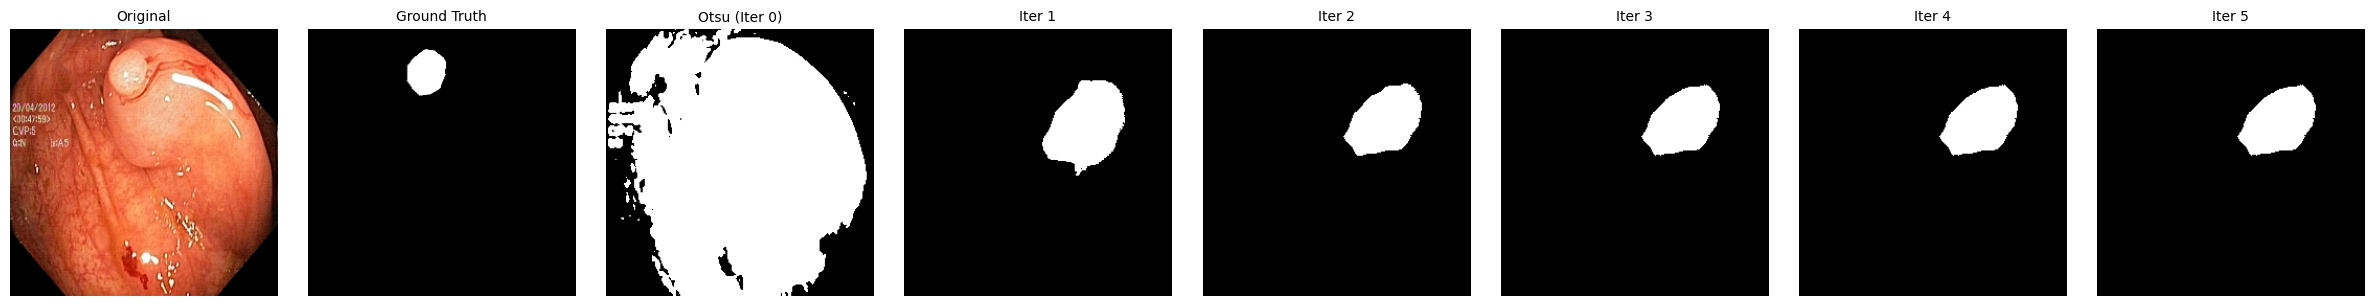


Sample 2: cju2t2ivz43i10878zeg8r1br.jpg


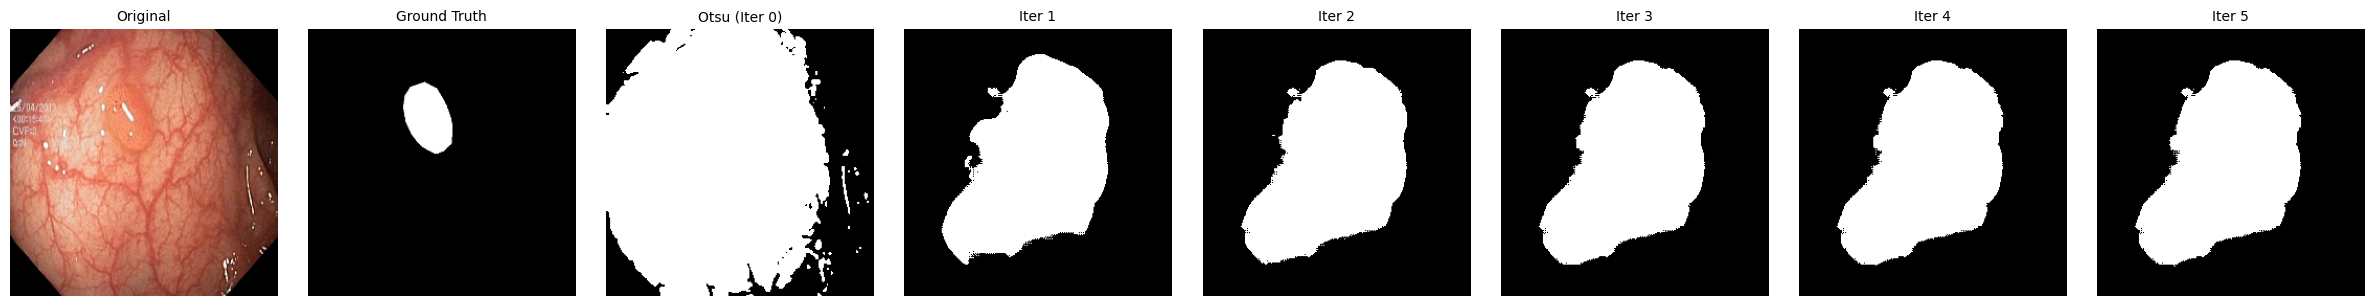


Sample 3: cju5cjh3xattc0817j2vbulzi.jpg


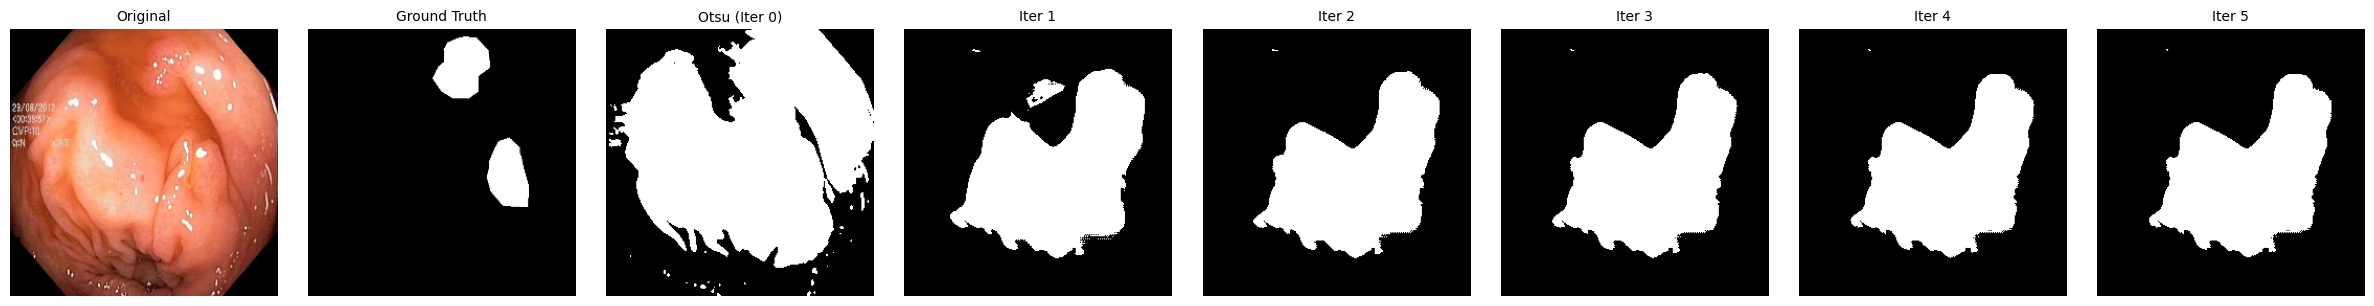

In [12]:
import matplotlib.pyplot as plt

def show_sample(model, img_path, mask_path, n_iter=5):
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    img = cv2.resize(img, (256, 256))
    img_t = torch.from_numpy(np.transpose(img, (2, 0, 1)) / 255.0).float().unsqueeze(0).to(device)

    gt = cv2.resize(cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE), (256, 256))

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    prev = (th / 255.0 > 0.5).astype(np.float32)

    preds = [th]
    prev_t = torch.from_numpy(prev).unsqueeze(0).unsqueeze(0).to(device)

    for _ in range(n_iter):
        with torch.no_grad():
            pb = (torch.sigmoid(model([img_t, prev_t])) > 0.5).float().cpu().squeeze().numpy()
            preds.append((pb * 255).astype(np.uint8))
            prev_t = torch.from_numpy(pb).unsqueeze(0).unsqueeze(0).to(device)

    fig, axes = plt.subplots(1, n_iter + 3, figsize=(3 * (n_iter + 3), 3))
    titles = ["Original", "Ground Truth", "Otsu (Iter 0)"] + [f"Iter {i+1}" for i in range(n_iter)]
    images = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB), gt] + preds

    for ax, title, im in zip(axes, titles, images):
        ax.imshow(im, cmap='gray' if len(im.shape) == 2 else None)
        ax.set_title(title, fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

for i in range(3):
    print(f"\nSample {i+1}: {os.path.basename(valid_x[i])}")
    show_sample(model, valid_x[i], valid_y[i])

## 12. Summary

In [13]:
print("=" * 55)
print("FANet Training & Evaluation Complete")
print("=" * 55)
print(f"Dataset:    Kvasir-SEG ({len(train_x)} train / {len(valid_x)} val)")
print(f"Model:      {sum(p.numel() for p in model.parameters()):,} params (FANet)")
print(f"Device:     {device}")
print(f"Epochs:     {NUM_EPOCHS}")
print(f"Best Val:   {best_val:.4f}")
print(f"Checkpoint: {CKPT}")
print(f"\nFinal Metrics (Iter {N_ITER-1}):")
for n, v in zip(NAMES, results[-1]):
    print(f"  {n:<14s}: {v:.4f}")
print(f"\nBest Dice:  {max(r[1] for r in results):.4f} (Iter {best_iter})")

FANet Training & Evaluation Complete
Dataset:    Kvasir-SEG (156 train / 40 val)
Model:      7,720,266 params (FANet)
Device:     cuda
Epochs:     200
Best Val:   0.5415
Checkpoint: checkpoint.pth

Final Metrics (Iter 9):
  IoU           : 0.1275
  Dice          : 0.2032
  Recall        : 0.3434
  Precision     : 0.2512
  Specificity   : 0.9258
  Accuracy      : 0.8714
  F2            : 0.2345

Best Dice:  0.2430 (Iter 0)
